# BinX AI & ML Internship
## Week 5 — Day 1: Hands-On Lab — K-Means Clustering

**Objective:** Apply the full K-Means workflow on the insurance dataset —
scale the features, find the best k using the elbow method and silhouette
score, fit the final model, and interpret each cluster as a real-world
patient segment.

**Dataset:** Medical Cost Personal Dataset (Week 2) — 1,338 patients

**Steps:**
1. Load and inspect the data
2. Quick EDA on numeric features
3. Scale features with StandardScaler
4. Elbow method (k=1 to 10)
5. Silhouette score for candidate k values
6. Fit final K-Means with chosen k
7. Visualize clusters
8. Build cluster profiles and interpret each segment


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings("ignore")


SEED = 42
plt.style.use("seaborn-v0_8-whitegrid")


## Step 1 — Load & Inspect the Data

I use the insurance dataset from Week 2. This time there is no target column
to predict — I want to see if K-Means can discover meaningful patient groups
from demographic and health features alone.

I'll include `charges` in the clustering so the algorithm can discover
cost-related segments naturally, then interpret what each group represents.


In [2]:
df = pd.read_csv("../../Week2/Day 1/data/insurance.csv")


# Basic inspection
print(f"Shape: {df.shape}")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nFirst 5 rows:")
df.head()


Shape: (1338, 7)

Column types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values: 0

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Step 2 — Quick EDA

Before clustering, I check the distributions of the numeric features.
K-Means works on numeric features — `sex`, `smoker`, and `region`
are categorical and will be excluded from clustering.


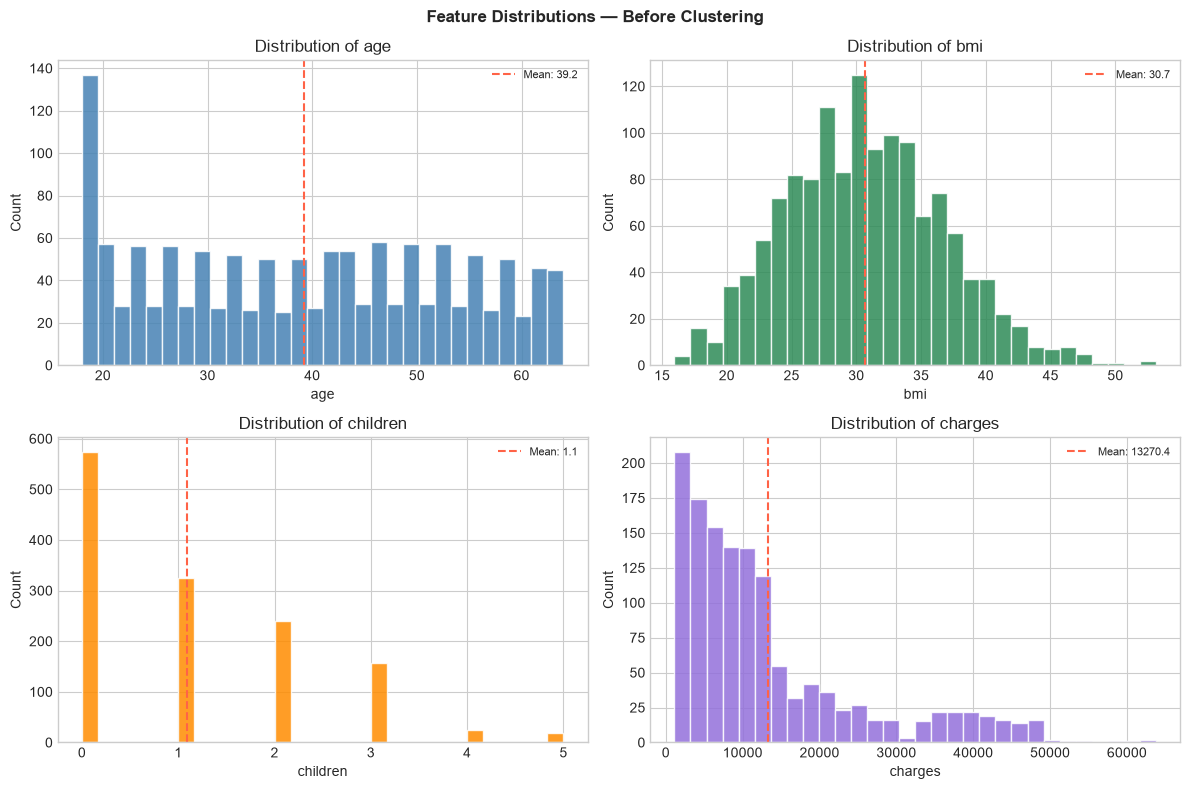

In [3]:
numeric_cols = ["age", "bmi", "children", "charges"]


# One histogram per feature, mean line included
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
colors = ["steelblue", "seagreen", "darkorange", "mediumpurple"]

for ax, col, color in zip(axes, numeric_cols, colors):

    ax.hist(
        df[col],
        bins=30,
        color=color,
        edgecolor="white",
        alpha=0.85
    )

    # Mean reference line
    ax.axvline(
        df[col].mean(),
        color="tomato",
        linestyle="--",
        linewidth=1.5,
        label=f"Mean: {df[col].mean():.1f}"
    )

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)


plt.suptitle(
    "Feature Distributions — Before Clustering",
    fontsize=12,
    fontweight="bold"
)
plt.tight_layout()
plt.show()


## Step 3 — Scale the Features

Before running K-Means, I apply `StandardScaler` to all four numeric features.

Without scaling, `charges` (range: \$1,122–\$63,770) would dominate
the distance calculations completely. The clusters would be determined
almost entirely by cost, ignoring age, BMI, and family size.


In [4]:
X = df[numeric_cols].copy()


# Fit and transform — scaler learns mean + std from this data only
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Verify: every feature should now have mean ≈ 0 and std ≈ 1
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)

print("After StandardScaler — mean and std per feature:")
print(f"{'Feature':<12} {'Mean':>8} {'Std':>8}")
print("-" * 30)

for col in numeric_cols:
    print(
        f"{col:<12} "
        f"{X_scaled_df[col].mean():>8.4f} "
        f"{X_scaled_df[col].std():>8.4f}"
    )


After StandardScaler — mean and std per feature:
Feature          Mean      Std
------------------------------
age           -0.0000   1.0004
bmi           -0.0000   1.0004
children      -0.0000   1.0004
charges       -0.0000   1.0004


## Step 4 — Elbow Method

I run K-Means for k=1 to 10 and record the inertia at each k.
The plot should show a clear elbow where the rate of improvement
drops sharply — that point is a good candidate for k.


In [5]:
inertias = []


# Fit K-Means for each k and record inertia
for k in range(1, 11):

    km = KMeans(
        n_clusters=k,
        random_state=SEED,
        n_init=10          # run 10 times, keep best result
    )
    km.fit(X_scaled)
    inertias.append(km.inertia_)


# Print inertia table — the drop column shows where improvement slows
print(f"{'k':<5} {'Inertia':>10} {'Drop':>10}")
print("-" * 27)

for i, (k, inertia) in enumerate(zip(range(1, 11), inertias)):
    drop = f"{inertias[i-1] - inertia:.1f}" if i > 0 else "—"
    print(f"{k:<5} {inertia:>10.1f} {drop:>10}")


k        Inertia       Drop
---------------------------
1         5352.0          —
2         4087.8     1264.2
3         3311.8      776.0
4         2572.3      739.5
5         2208.4      363.9
6         1983.6      224.9
7         1799.4      184.2
8         1659.6      139.8
9         1557.3      102.4
10        1454.4      102.8


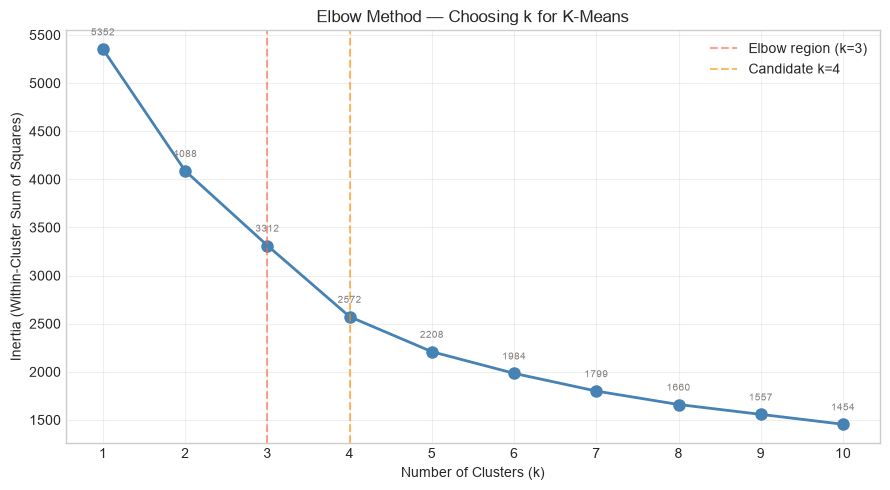

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))


# Main inertia line
ax.plot(
    range(1, 11),
    inertias,
    marker="o",
    color="steelblue",
    linewidth=2,
    markersize=8
)


# Mark the elbow candidates
ax.axvline(
    x=3, color="tomato",
    linestyle="--", alpha=0.6,
    label="Elbow region (k=3)"
)
ax.axvline(
    x=4, color="darkorange",
    linestyle="--", alpha=0.6,
    label="Candidate k=4"
)


# Annotate each point with its inertia value
for k, inertia in zip(range(1, 11), inertias):
    ax.annotate(
        f"{inertia:.0f}",
        xy=(k, inertia),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center", fontsize=7, color="gray"
    )


ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia (Within-Cluster Sum of Squares)")
ax.set_title("Elbow Method — Choosing k for K-Means")
ax.set_xticks(range(1, 11))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Reading the elbow plot:**

The steepest drops occur at k=2 and k=3.
After k=4, the improvement per additional cluster drops below 400 —
roughly half the improvement seen at k=2.

The elbow is not perfectly sharp here — which is common with real-world data.
The candidates are **k=3** and **k=4**.
I'll use the silhouette score to decide between them.


## Step 5 — Silhouette Score

I compute the mean silhouette score for k=2 through k=6.
The highest score indicates the most well-defined cluster structure.


In [7]:
sil_scores = {}


# Fit K-Means for each candidate and compute the silhouette score
for k in range(2, 7):

    km = KMeans(
        n_clusters=k,
        random_state=SEED,
        n_init=10
    )
    labels = km.fit_predict(X_scaled)

    # silhouette_score returns the mean score across all points
    sil_scores[k] = silhouette_score(X_scaled, labels)

    print(f"k={k}:  silhouette = {sil_scores[k]:.3f}")


# Best k is the one with the highest mean silhouette score
best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest k by silhouette: {best_k} (score = {sil_scores[best_k]:.3f})")


k=2:  silhouette = 0.234
k=3:  silhouette = 0.257
k=4:  silhouette = 0.294
k=5:  silhouette = 0.282
k=6:  silhouette = 0.257

Best k by silhouette: 4 (score = 0.294)


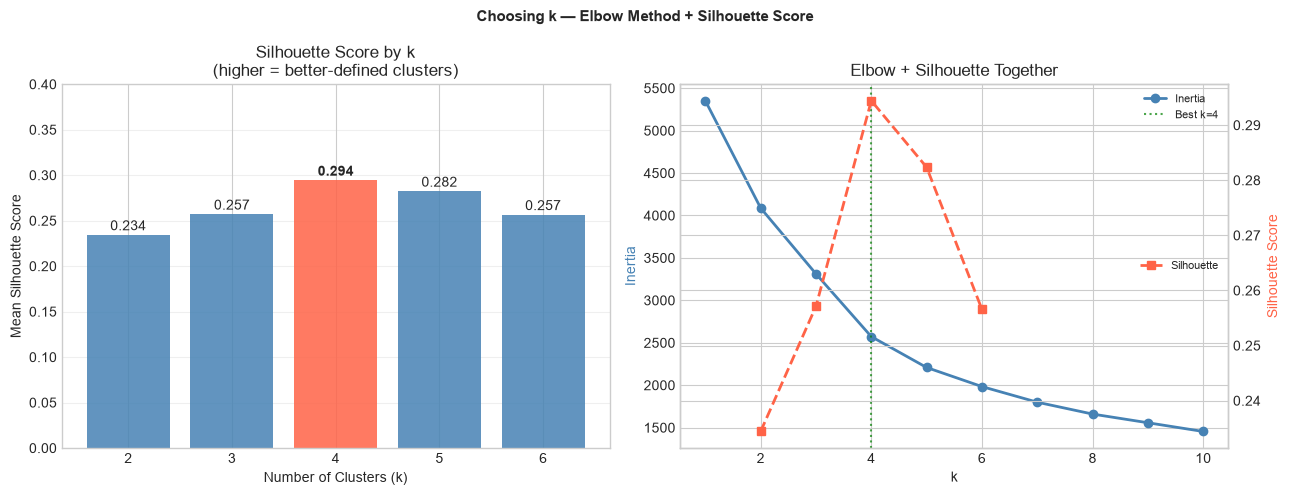

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))


# Left — bar chart: silhouette score per k
colors_bar = [
    "tomato" if k == best_k else "steelblue"
    for k in sil_scores.keys()
]
bars = axes[0].bar(
    [str(k) for k in sil_scores.keys()],
    sil_scores.values(),
    color=colors_bar,
    alpha=0.85
)

# Label each bar with its exact score
for bar, (k, score) in zip(bars, sil_scores.items()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.005,
        f"{score:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold" if k == best_k else "normal"
    )

axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Mean Silhouette Score")
axes[0].set_title("Silhouette Score by k\n(higher = better-defined clusters)")
axes[0].set_ylim(0, 0.4)
axes[0].grid(alpha=0.3, axis="y")


# Right — elbow + silhouette on the same chart
ax2 = axes[1]
ax2_twin = ax2.twinx()    # second y-axis for silhouette

ax2.plot(
    range(1, 11), inertias,
    marker="o", color="steelblue",
    linewidth=2, label="Inertia"
)
ax2_twin.plot(
    list(sil_scores.keys()),
    list(sil_scores.values()),
    marker="s", color="tomato",
    linewidth=2, linestyle="--",
    label="Silhouette"
)

# Mark the chosen k
ax2.axvline(
    x=best_k, color="green",
    linestyle=":", alpha=0.7,
    label=f"Best k={best_k}"
)

ax2.set_xlabel("k")
ax2.set_ylabel("Inertia", color="steelblue")
ax2_twin.set_ylabel("Silhouette Score", color="tomato")
ax2.set_title("Elbow + Silhouette Together")
ax2.legend(loc="upper right", fontsize=8)
ax2_twin.legend(loc="center right", fontsize=8)


plt.suptitle(
    "Choosing k — Elbow Method + Silhouette Score",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()


**Decision: k=4**

Both methods agree:
- **Elbow:** the largest relative drop occurs before k=4
- **Silhouette:** k=4 has the highest mean score (0.294)

The silhouette scores are in the 0.25–0.30 range —
"weak to reasonable structure" by the standard interpretation table.
This is typical for real-world tabular data where clusters
overlap rather than being perfectly separated.
It doesn't mean the clusters are useless — it means they
represent tendencies in the data, not hard boundaries.


## Step 6 — Fit Final K-Means with k=4

In [9]:
# Fit the final model with the chosen k
km_final = KMeans(
    n_clusters=best_k,
    random_state=SEED,
    n_init=10
)
labels = km_final.fit_predict(X_scaled)


# Add cluster labels back to the original (unscaled) dataframe
df["cluster"] = labels


# Cluster sizes
print(f"K-Means fitted with k={best_k}")
print(f"\nCluster sizes:")
print(df["cluster"].value_counts().sort_index().to_string())


# Centroids in original scale — inverse_transform undoes the StandardScaler
centroids_orig = scaler.inverse_transform(km_final.cluster_centers_)
centroids_df = pd.DataFrame(centroids_orig, columns=numeric_cols)

print(f"\nCentroid positions (original scale):")
print(centroids_df.round(1).to_string())


K-Means fitted with k=4

Cluster sizes:
cluster
0    408
1    165
2    346
3    419

Centroid positions (original scale):
    age   bmi  children  charges
0  52.5  30.9       0.4  12593.0
1  39.9  35.3       1.1  40308.3
2  39.9  30.0       2.7  10709.6
3  25.4  29.2       0.4   5397.4


## Step 7 — Visualize the Clusters

Since the data has 4 dimensions, I use 2D scatter plots —
one for age vs charges and one for BMI vs charges —
to show where the clusters sit in the feature space.
Stars mark the centroid of each cluster.


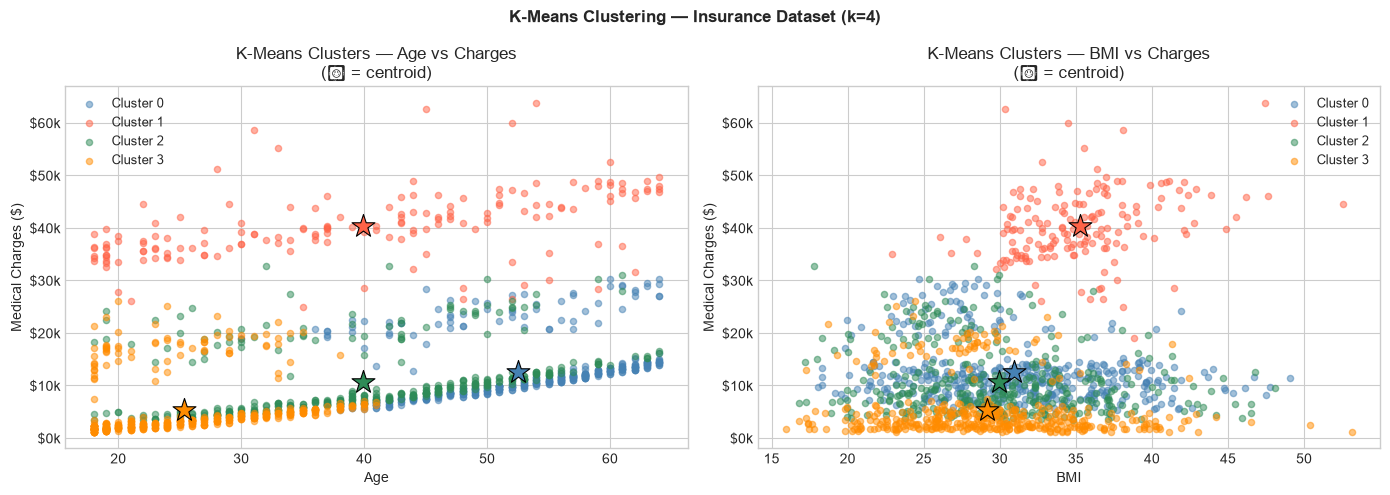

In [10]:
cluster_colors = {
    0: "steelblue",
    1: "tomato",
    2: "seagreen",
    3: "darkorange"
}


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# ── Left: age vs charges ──────────────────────────────────────────────────
for c in range(best_k):
    mask = df["cluster"] == c
    axes[0].scatter(
        df.loc[mask, "age"],
        df.loc[mask, "charges"],
        c=cluster_colors[c],
        label=f"Cluster {c}",
        alpha=0.5, s=20
    )

# Centroids as stars
for c in range(best_k):
    axes[0].scatter(
        centroids_df.loc[c, "age"],
        centroids_df.loc[c, "charges"],
        c=cluster_colors[c],
        marker="*", s=300,
        edgecolors="black", linewidths=0.8,
        zorder=5
    )

axes[0].set_xlabel("Age")
axes[0].set_ylabel("Medical Charges ($)")
axes[0].set_title("K-Means Clusters — Age vs Charges\n(★ = centroid)")
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
)


# ── Right: bmi vs charges ─────────────────────────────────────────────────
for c in range(best_k):
    mask = df["cluster"] == c
    axes[1].scatter(
        df.loc[mask, "bmi"],
        df.loc[mask, "charges"],
        c=cluster_colors[c],
        label=f"Cluster {c}",
        alpha=0.5, s=20
    )

# Centroids
for c in range(best_k):
    axes[1].scatter(
        centroids_df.loc[c, "bmi"],
        centroids_df.loc[c, "charges"],
        c=cluster_colors[c],
        marker="*", s=300,
        edgecolors="black", linewidths=0.8,
        zorder=5
    )

axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Medical Charges ($)")
axes[1].set_title("K-Means Clusters — BMI vs Charges\n(★ = centroid)")
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
)


plt.suptitle(
    "K-Means Clustering — Insurance Dataset (k=4)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()


## Step 8 — Cluster Profiles

I add the cluster labels back to the original dataframe and use
`groupby` to compute the mean of each feature per cluster —
including `smoker`, which was not used in the clustering.


In [11]:
# Aggregate each feature by cluster
profile = df.groupby("cluster").agg(
    count        = ("age",     "count"),
    avg_age      = ("age",     "mean"),
    avg_bmi      = ("bmi",     "mean"),
    avg_children = ("children", "mean"),
    avg_charges  = ("charges",  "mean"),
    pct_smokers  = ("smoker",   lambda x: (x == "yes").mean())
).round(2)


# Format for display
profile["avg_charges"] = profile["avg_charges"].apply(lambda x: f"${x:,.0f}")
profile["pct_smokers"] = profile["pct_smokers"].apply(lambda x: f"{x:.1%}")

print("Cluster Profiles:")
print(profile.to_string())


Cluster Profiles:
         count  avg_age  avg_bmi  avg_children avg_charges pct_smokers
cluster                                                               
0          408    52.51    30.93          0.43     $12,593       10.0%
1          165    39.87    35.30          1.15     $40,308       90.0%
2          346    39.94    29.96          2.68     $10,710       12.0%
3          419    25.38    29.16          0.41      $5,397       10.0%


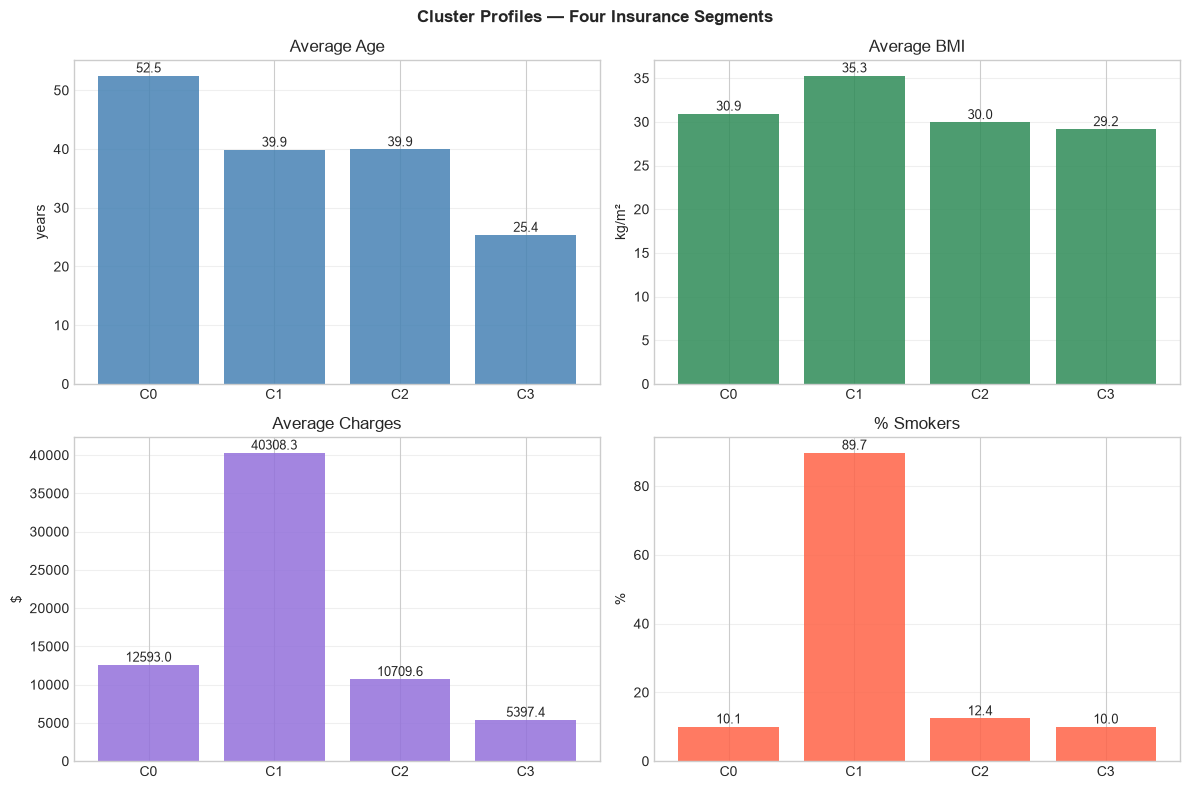

In [12]:
# Visual comparison of the four clusters across key metrics

raw_profile = df.groupby("cluster").agg(
    avg_age     = ("age",     "mean"),
    avg_bmi     = ("bmi",     "mean"),
    avg_charges = ("charges",  "mean"),
    pct_smokers = ("smoker",   lambda x: (x == "yes").mean() * 100)
).round(2)


metrics = {
    "avg_age":      ("Average Age",      "years",     "steelblue"),
    "avg_bmi":      ("Average BMI",      "kg/m²",     "seagreen"),
    "avg_charges":  ("Average Charges",  "$",         "mediumpurple"),
    "pct_smokers":  ("% Smokers",        "%",         "tomato")
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (metric, (title, unit, color)) in zip(
    axes.flatten(), metrics.items()
):
    vals = raw_profile[metric]
    bars = ax.bar(
        [f"C{i}" for i in range(best_k)],
        vals, color=color, alpha=0.85
    )

    # Label each bar with its exact value
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + vals.max() * 0.01,
            f"{val:.1f}",
            ha="center", fontsize=9
        )

    ax.set_title(title)
    ax.set_ylabel(unit)
    ax.grid(alpha=0.3, axis="y")


plt.suptitle(
    "Cluster Profiles — Four Insurance Segments",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()


## Step 8.1 — Silhouette Plot

The mean silhouette score tells me overall cluster quality.
The silhouette plot shows how each individual point scored —
and which clusters are the most internally consistent.


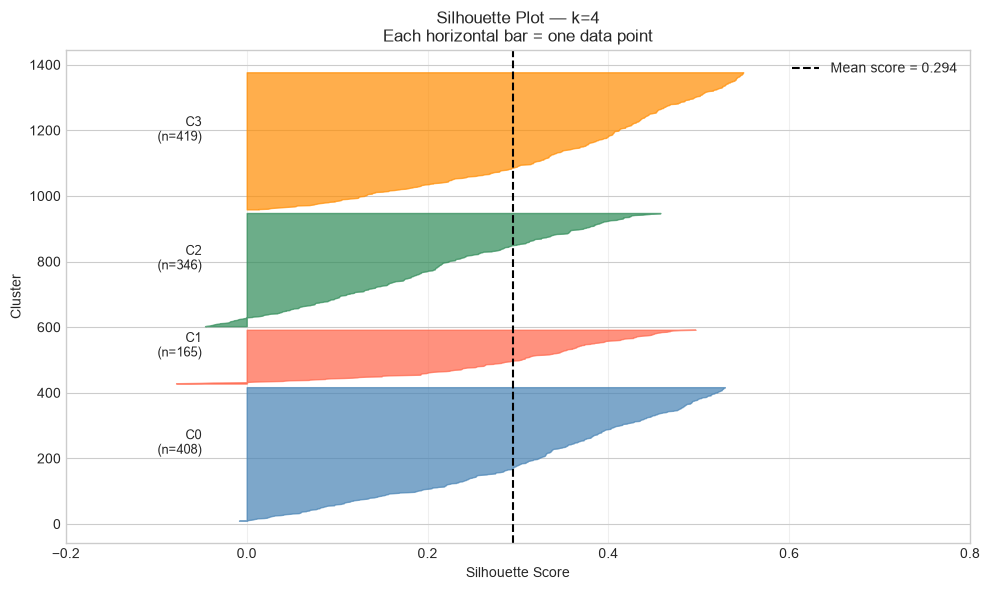

Average silhouette per cluster:
  Cluster 0: 0.311
  Cluster 1: 0.293
  Cluster 2: 0.204
  Cluster 3: 0.354


In [13]:
# Compute per-point silhouette scores
sil_vals = silhouette_samples(X_scaled, labels)


fig, ax = plt.subplots(figsize=(10, 6))

y_lower = 10
cluster_colors_list = list(cluster_colors.values())

for c in range(best_k):

    # Sort scores for this cluster so bars are stacked neatly
    cluster_sil = np.sort(sil_vals[labels == c])
    size = cluster_sil.shape[0]
    y_upper = y_lower + size

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, cluster_sil,
        alpha=0.7,
        color=cluster_colors_list[c]
    )

    # Cluster label on the left
    ax.text(
        -0.05, y_lower + size / 2,
        f"C{c}\n(n={size})",
        ha="right", fontsize=9
    )

    y_lower = y_upper + 10


# Mean score reference line
ax.axvline(
    x=sil_scores[best_k],
    color="black", linestyle="--", linewidth=1.5,
    label=f"Mean score = {sil_scores[best_k]:.3f}"
)

ax.set_xlabel("Silhouette Score")
ax.set_ylabel("Cluster")
ax.set_title(
    f"Silhouette Plot — k={best_k}\n"
    f"Each horizontal bar = one data point"
)
ax.legend(fontsize=10)
ax.set_xlim(-0.2, 0.8)
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()


# Average silhouette per cluster
print("Average silhouette per cluster:")
for c in range(best_k):
    mask = labels == c
    print(f"  Cluster {c}: {sil_vals[mask].mean():.3f}")


**Reading the silhouette plot:**

Each horizontal bar is one data point's silhouette score.

- **Cluster 3** (young, low-cost) has the highest average (0.354) —
  the most internally consistent group.
- **Cluster 1** (high-cost smokers) is well-defined (0.293) despite
  being the smallest — the smoking pattern creates a tight, distinct group.
- **Cluster 2** (mid-age families) has the lowest average (0.204) —
  some points genuinely sit between clusters.

Points with negative scores are closer to another cluster than their own.
Those are the natural overlap zones between neighboring segments.


## Step 9 — Interpreting the Clusters

The four clusters correspond to distinct real-world patient profiles.


**Cluster 0 — Older, Mid-Cost (n=408, 30.5%)**

Average age: 52.5 | Average charges: \$12,593 | Smokers: 10%

Older patients with moderate medical costs. Their charges are higher
than younger clusters — consistent with age-related health needs —
but far below the smoker cluster. Very few smokers.

Interpretation: **aging non-smokers**. Costs reflect normal health
deterioration with age, not lifestyle-driven expenses.

---

**Cluster 1 — High-Cost Smokers (n=165, 12.3%)**

Average age: 39.9 | Average charges: \$40,308 | Smokers: 89.7%

By far the highest-cost group — nearly 4× the population mean (\$13,270).
Nearly 9 in 10 are smokers. K-Means discovered this segment without
being told about smoking — the signal was strong enough to create
its own cluster purely from the patterns in the data.

Interpretation: **smoker cluster** — lifestyle-driven high risk.

---

**Cluster 2 — Mid-Age Families (n=346, 25.9%)**

Average age: 39.9 | Average charges: \$10,710 | Children: 2.7 | Smokers: 12.4%

Similar age to Cluster 1 but very different costs — because most
are non-smokers. The distinguishing feature is family size (2.7
children vs 0.4 in other clusters).

Interpretation: **young families**. Higher-than-youngest charges
reflect family healthcare needs, not lifestyle risk.

---

**Cluster 3 — Young, Low-Cost (n=419, 31.3%)**

Average age: 25.4 | Average charges: \$5,397 | Smokers: 10%

Youngest group with the lowest costs and highest silhouette score (0.354).
Very few smokers and no established age-related conditions.

Interpretation: **healthy young adults** — low medical costs driven
by youth and low lifestyle risk.


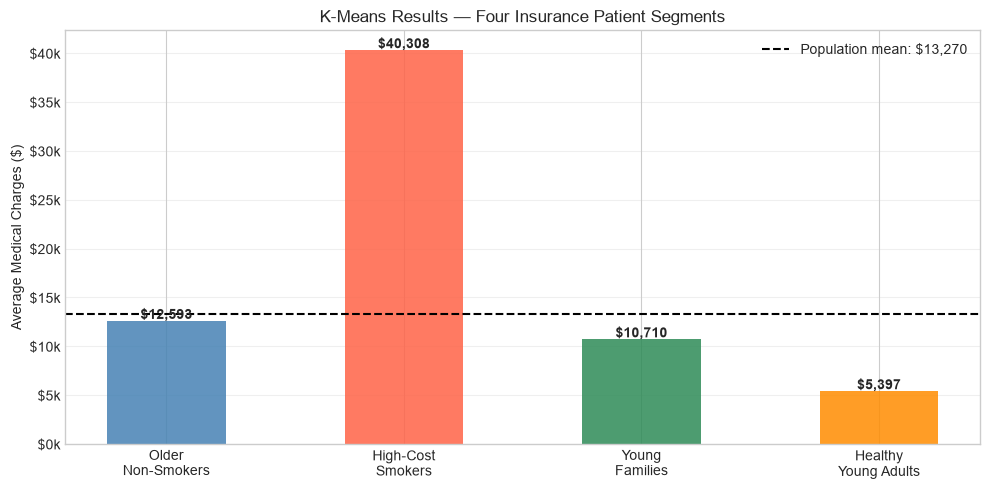

In [14]:
# Final bar chart — average charges per named segment

cluster_names = {
    0: "Older\nNon-Smokers",
    1: "High-Cost\nSmokers",
    2: "Young\nFamilies",
    3: "Healthy\nYoung Adults"
}

raw_charges = df.groupby("cluster")["charges"].mean()


fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    [cluster_names[c] for c in range(best_k)],
    raw_charges.values,
    color=list(cluster_colors.values()),
    alpha=0.85, width=0.5
)

# Population mean reference line
ax.axhline(
    df["charges"].mean(),
    color="black", linestyle="--", linewidth=1.5,
    label=f"Population mean: ${df['charges'].mean():,.0f}"
)

# Label each bar with its dollar value
for bar, val in zip(bars, raw_charges.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 200,
        f"${val:,.0f}",
        ha="center", fontsize=10, fontweight="bold"
    )

ax.set_ylabel("Average Medical Charges ($)")
ax.set_title("K-Means Results — Four Insurance Patient Segments")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
)
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


## What I Learned Today

**Unsupervised learning** works without labels — the goal is to discover
hidden structure, not predict a known answer.

**K-Means** finds k groups by minimizing total within-cluster distance.
The centroid-assignment loop repeats until stable.

**Two tools for choosing k:**
- Elbow method: find where adding more clusters gives diminishing returns
- Silhouette score: quantify how well each point fits its cluster

**Scaling is mandatory** — K-Means uses distance, and an unscaled
large-range feature like `charges` would dominate every assignment.

**The most important finding today:**
K-Means discovered the smoker segment (Cluster 1) without being
told about smoking. The algorithm found a group of 165 people
with 89.7% smoking rate — purely from the shape of the data.
That's what unsupervised learning does: it reveals structure
that wasn't explicitly labeled.

**Tomorrow — Day 2:**
K-Means requires k in advance, assumes round clusters, and forces
every point into a cluster. DBSCAN and hierarchical clustering
address these weaknesses.
